# NLP Coursework
### Patronising and Condescending Language (PCL) Detection


### 0. Setup: Install Dependencies & Download Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.chdir('/content/drive/MyDrive/ColabNotebooks/nlp-pcl')
print(os.getcwd())

/content/drive/MyDrive/ColabNotebooks/nlp-pcl


In [ ]:
# Install required libraries (wordcloud not available by default in Colab)
!pip install wordcloud -q

In [ ]:
import os
import re
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams

# Download required NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

print('All imports successful.')

All imports successful.


### 1. Load and Prepare the Dataset

In [ ]:
# ---------------------------------------------------------------
# Load the main TSV file. Columns:
#   par_id, art_id, keyword, country_code, text, label (0-4 scale)
# ---------------------------------------------------------------

df = pd.read_csv(
    'dontpatronizeme_pcl.tsv',
    sep='\t',
    header=None,
    names=['par_id', 'art_id', 'keyword', 'country_code', 'text', 'label'],
    skiprows=4,
    quoting=3
)

print(f'Total paragraphs loaded: {len(df)}')
print(f'Label distribution (0-4 scale):\n{df["label"].value_counts().sort_index()}')

Total paragraphs loaded: 10469
Label distribution (0-4 scale):
label
0    8529
1     947
2     144
3     458
4     391
Name: count, dtype: int64


In [ ]:
# ---------------------------------------------------------------
# Convert the 5-point scale to binary labels per the task spec:
#   Labels 0-1  -->  No PCL (0)
#   Labels 2-4  -->  PCL    (1)
# Then split into Train / Dev using official paragraph ID files.
# ---------------------------------------------------------------

df['binary_label'] = (df['label'] >= 2).astype(int)

def load_par_ids(filepath):
    ids = set()
    with open(filepath, 'r') as f:
        next(f)  # skip header row in the CSV
        for line in f:
            line = line.strip()
            if line:
                par_id = line.split(',')[0].strip()
                ids.add(par_id)
    return ids

train_ids = load_par_ids('train_semeval_parids-labels.csv')
dev_ids   = load_par_ids('dev_semeval_parids-labels.csv')

df['par_id'] = df['par_id'].astype(str).str.strip()

train_df = df[df['par_id'].isin(train_ids)].copy()
dev_df   = df[df['par_id'].isin(dev_ids)].copy()

print(f'Train set size : {len(train_df)}')
print(f'Dev   set size : {len(dev_df)}')
print(f'\nTrain binary label distribution:\n{train_df["binary_label"].value_counts()}')

Train set size : 8375
Dev   set size : 2094

Train binary label distribution:
binary_label
0    7581
1     794
Name: count, dtype: int64


#Exercise 2


### EDA Technique 1: Basic Statistical Profiling

In [ ]:
# ---------------------------------------------------------------
# Tokenise each paragraph and compute per-token counts.
# We use NLTK's word_tokenize for consistency with downstream steps.
# ---------------------------------------------------------------

train_df['tokens']      = train_df['text'].apply(word_tokenize)
train_df['token_count'] = train_df['tokens'].apply(len)

# Summary statistics per class
stats = train_df.groupby('binary_label')['token_count'].agg(
    Mean='mean', Median='median', Min='min', Max='max', Std='std'
).round(1)
stats.index = ['No PCL (0)', 'PCL (1)']

print('Token Count Statistics by Class:')
print(stats.to_string())

Token Count Statistics by Class:
            Mean  Median  Min  Max   Std
No PCL (0)  49.4    43.0    1  918  29.8
PCL (1)     55.1    49.0    6  520  34.1


In [ ]:
# ---------------------------------------------------------------
# Vocabulary size: count unique lowercase tokens per class
# and overall across the full training set.
# ---------------------------------------------------------------

all_tokens   = [t.lower() for toks in train_df['tokens'] for t in toks]
pcl_tokens   = [t.lower() for toks in train_df[train_df['binary_label']==1]['tokens'] for t in toks]
nopcl_tokens = [t.lower() for toks in train_df[train_df['binary_label']==0]['tokens'] for t in toks]

print(f'Overall vocabulary size : {len(set(all_tokens)):,} unique tokens')
print(f'PCL vocabulary size     : {len(set(pcl_tokens)):,} unique tokens')
print(f'No-PCL vocabulary size  : {len(set(nopcl_tokens)):,} unique tokens')

Overall vocabulary size : 29,311 unique tokens
PCL vocabulary size     : 6,969 unique tokens
No-PCL vocabulary size  : 27,810 unique tokens


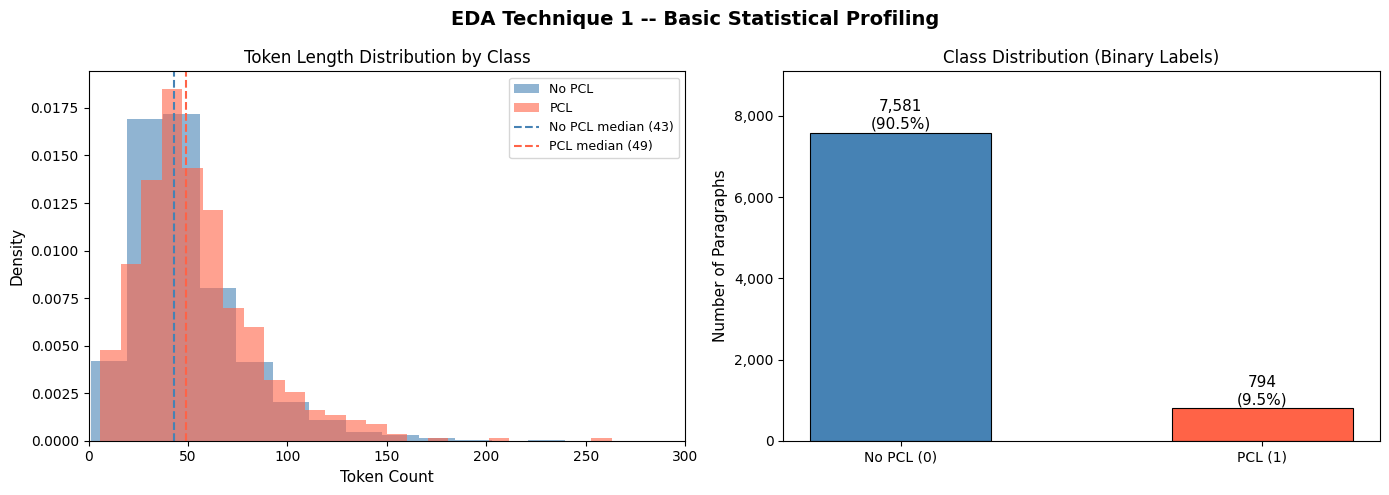

In [ ]:
# ---------------------------------------------------------------
# Figure 1a: Token length distribution (histogram, both classes)
# Figure 1b: Class distribution (bar chart with counts + %)
# ---------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EDA Technique 1 -- Basic Statistical Profiling', fontsize=14, fontweight='bold')

# --- 1a: Token length distribution ---
pcl_lengths   = train_df[train_df['binary_label']==1]['token_count']
nopcl_lengths = train_df[train_df['binary_label']==0]['token_count']

axes[0].hist(nopcl_lengths, bins=50, alpha=0.6, color='steelblue', label='No PCL', density=True)
axes[0].hist(pcl_lengths,   bins=50, alpha=0.6, color='tomato',    label='PCL',    density=True)
axes[0].axvline(nopcl_lengths.median(), color='steelblue', linestyle='--', linewidth=1.5,
                label=f'No PCL median ({int(nopcl_lengths.median())})')
axes[0].axvline(pcl_lengths.median(),   color='tomato',    linestyle='--', linewidth=1.5,
                label=f'PCL median ({int(pcl_lengths.median())})')
axes[0].set_xlabel('Token Count', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title('Token Length Distribution by Class')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 300)

# --- 1b: Class distribution ---
class_counts = train_df['binary_label'].value_counts().sort_index()
total = class_counts.sum()
bars = axes[1].bar(
    ['No PCL (0)', 'PCL (1)'],
    class_counts.values,
    color=['steelblue', 'tomato'],
    edgecolor='black', linewidth=0.8, width=0.5
)
for bar, count in zip(bars, class_counts.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f'{count:,}\n({100*count/total:.1f}%)',
        ha='center', va='bottom', fontsize=11
    )
axes[1].set_title('Class Distribution (Binary Labels)', fontsize=12)
axes[1].set_ylabel('Number of Paragraphs', fontsize=11)
axes[1].set_ylim(0, class_counts.max() * 1.2)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('eda_technique1_statistical_profiling.png', dpi=150, bbox_inches='tight')
plt.show()


## EDA Technique 2: Lexical Analysis

In [ ]:
# ---------------------------------------------------------------
# Prepare filtered token lists.
# For n-gram and word cloud analysis we remove stop words and
# punctuation to surface content-bearing terms.
# We keep the full token lists separately for stop word density.
# ---------------------------------------------------------------

STOPWORDS = set(stopwords.words('english'))

def get_clean_tokens(token_list, min_len=2):
    """Lowercase, remove stop words and non-alphabetic tokens."""
    return [
        t.lower() for t in token_list
        if t.isalpha() and len(t) >= min_len and t.lower() not in STOPWORDS
    ]

pcl_df   = train_df[train_df['binary_label'] == 1]
nopcl_df = train_df[train_df['binary_label'] == 0]

pcl_clean   = [t for toks in pcl_df['tokens']   for t in get_clean_tokens(toks)]
nopcl_clean = [t for toks in nopcl_df['tokens'] for t in get_clean_tokens(toks)]

print(f'PCL   -- content tokens (no stops): {len(pcl_clean):,}')
print(f'No-PCL -- content tokens (no stops): {len(nopcl_clean):,}')

PCL   -- content tokens (no stops): 19,812
No-PCL -- content tokens (no stops): 177,470


In [ ]:
# ---------------------------------------------------------------
# Stop Word Density: proportion of each paragraph's alpha tokens
# that are stop words. Computed per example, then averaged per class.
# ---------------------------------------------------------------

def stopword_density(token_list):
    alpha = [t.lower() for t in token_list if t.isalpha()]
    if not alpha:
        return 0.0
    return sum(1 for t in alpha if t in STOPWORDS) / len(alpha)

train_df['stop_density'] = train_df['tokens'].apply(stopword_density)

density_stats = train_df.groupby('binary_label')['stop_density'].agg(
    Mean='mean', Median='median', Std='std'
).round(3)
density_stats.index = ['No PCL', 'PCL']
print('Stop Word Density by Class:')
print(density_stats.to_string())

Stop Word Density by Class:
         Mean  Median    Std
No PCL  0.425   0.429  0.088
PCL     0.453   0.459  0.087


In [ ]:
# ---------------------------------------------------------------
# N-gram Analysis: compute top 15 bigrams and trigrams per class.
# Using stop-word-filtered tokens to surface meaningful phrases.
# ---------------------------------------------------------------

def top_ngrams(token_list, n, top_k=15):
    ng = list(ngrams(token_list, n))
    return Counter(ng).most_common(top_k)

pcl_bigrams    = top_ngrams(pcl_clean,   2)
nopcl_bigrams  = top_ngrams(nopcl_clean, 2)
pcl_trigrams   = top_ngrams(pcl_clean,   3)
nopcl_trigrams = top_ngrams(nopcl_clean, 3)

# Print bigrams
for label, ng_list in [('PCL Bigrams', pcl_bigrams), ('No-PCL Bigrams', nopcl_bigrams)]:
    print(f'\nTop 15 {label}:')
    for ng, count in ng_list:
        print(f'  {", ".join(ng):<35} {count}')


Top 15 PCL Bigrams:
  poor, families                      111
  people, need                        26
  homeless, people                    24
  children, poor                      19
  help, need                          14
  men, women                          11
  disabled, people                    10
  hundreds, thousands                 9
  vulnerable, people                  9
  hope, hopeless                      8
  help, people                        8
  sri, lanka                          8
  let, us                             8
  homeless, children                  8
  united, states                      7

Top 15 No-PCL Bigrams:
  poor, families                      609
  illegal, immigrants                 239
  per, cent                           134
  united, states                      128
  last, year                          95
  disabled, people                    92
  new, york                           85
  sri, lanka                          85
  homeless, peo

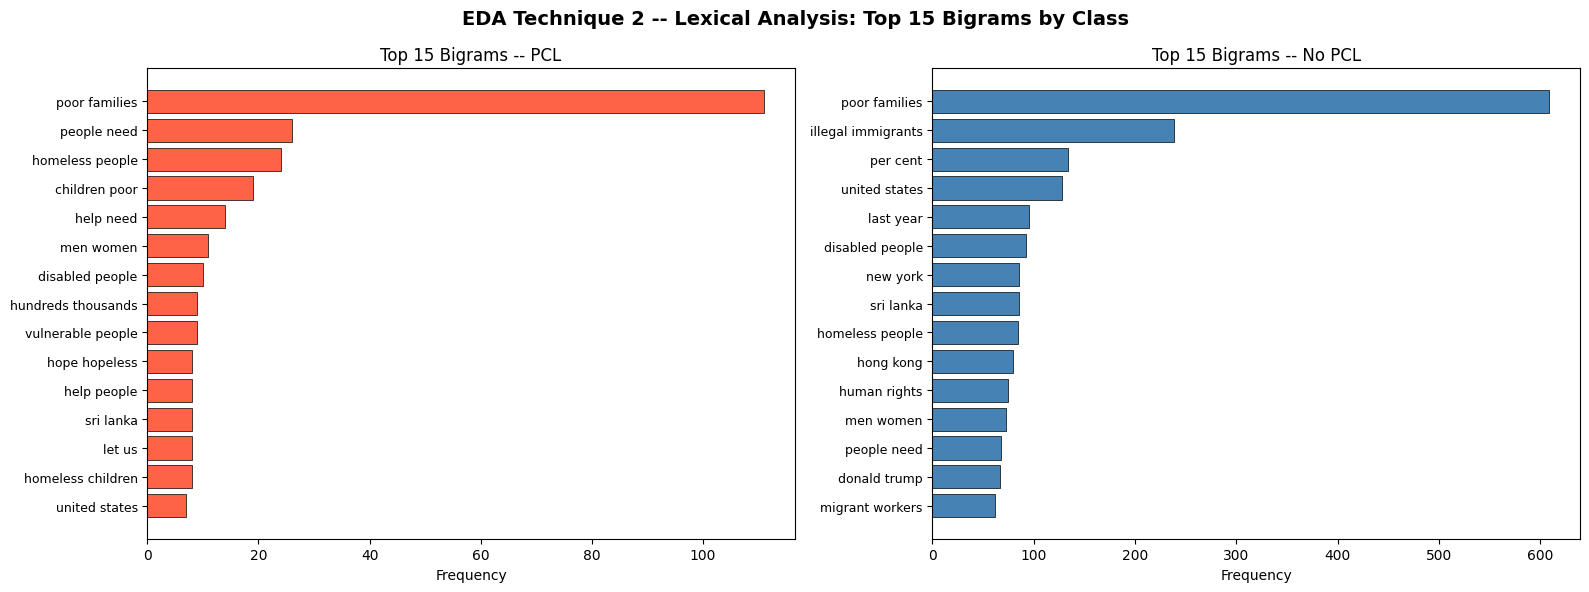

Figure 2a saved.


In [ ]:
# ---------------------------------------------------------------
# Figure 2a: Top 15 bigrams for PCL vs No-PCL (horizontal bars)
# ---------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('EDA Technique 2 -- Lexical Analysis: Top 15 Bigrams by Class',
             fontsize=14, fontweight='bold')

def plot_ngrams(ax, ngram_list, title, color):
    labels = [' '.join(ng) for ng, _ in ngram_list]
    counts = [c for _, c in ngram_list]
    ax.barh(labels[::-1], counts[::-1], color=color, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Frequency', fontsize=10)
    ax.tick_params(axis='y', labelsize=9)

plot_ngrams(axes[0], pcl_bigrams,   'Top 15 Bigrams -- PCL',    'tomato')
plot_ngrams(axes[1], nopcl_bigrams, 'Top 15 Bigrams -- No PCL', 'steelblue')

plt.tight_layout()
plt.savefig('eda_technique2a_bigrams.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2a saved.')

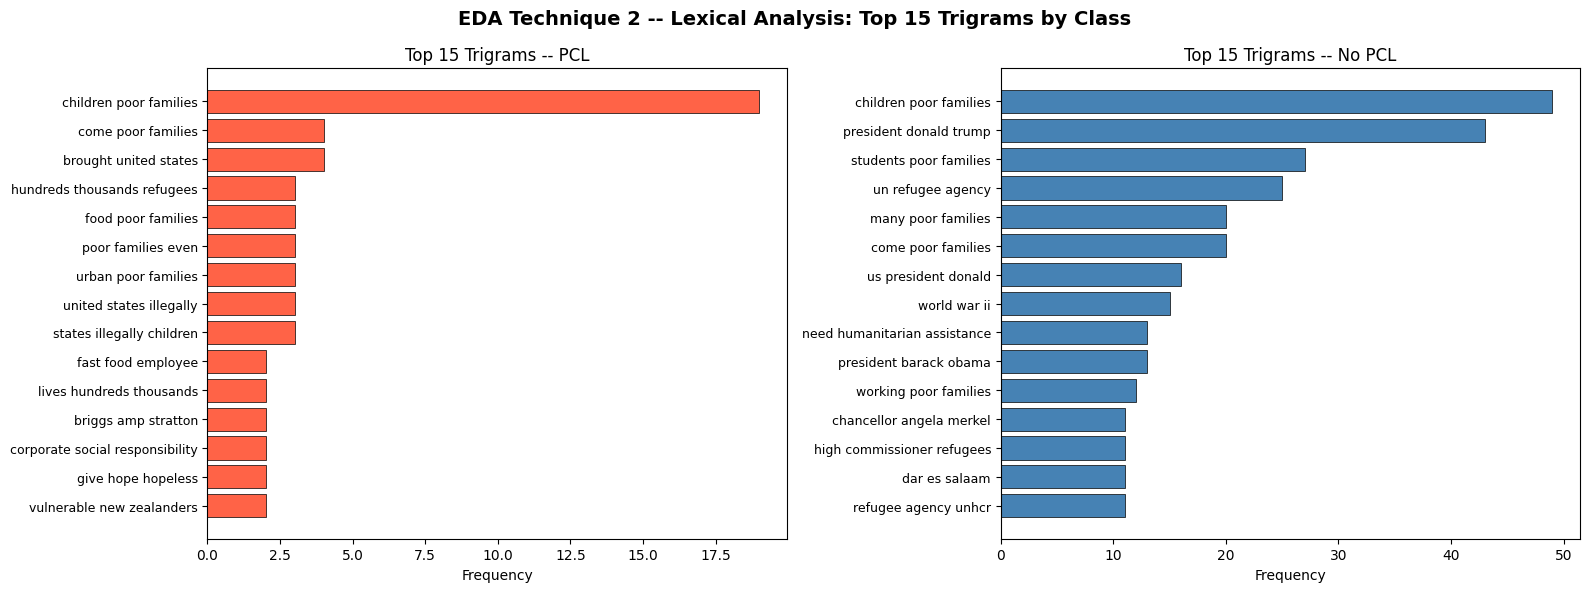

Figure 2b saved.


In [ ]:
# ---------------------------------------------------------------
# Figure 2b: Top 15 trigrams for PCL vs No-PCL (horizontal bars)
# ---------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('EDA Technique 2 -- Lexical Analysis: Top 15 Trigrams by Class',
             fontsize=14, fontweight='bold')

plot_ngrams(axes[0], pcl_trigrams,   'Top 15 Trigrams -- PCL',    'tomato')
plot_ngrams(axes[1], nopcl_trigrams, 'Top 15 Trigrams -- No PCL', 'steelblue')

plt.tight_layout()
plt.savefig('eda_technique2b_trigrams.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2b saved.')

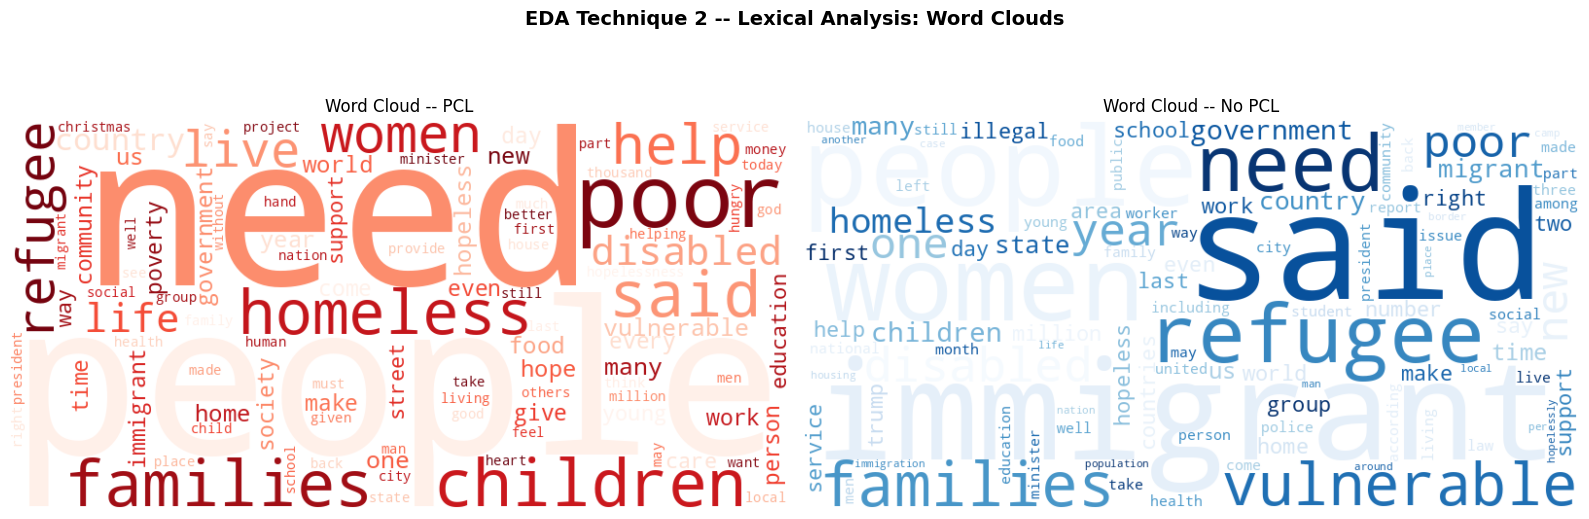

Figure 2c saved.


In [ ]:
# ---------------------------------------------------------------
# Figure 2c: Word clouds for PCL and No-PCL
# ---------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('EDA Technique 2 -- Lexical Analysis: Word Clouds',
             fontsize=14, fontweight='bold')

for ax, tokens, title, colormap in [
    (axes[0], pcl_clean,   'PCL',    'Reds'),
    (axes[1], nopcl_clean, 'No PCL', 'Blues')
]:
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=colormap,
        max_words=100,
        collocations=False
    ).generate(' '.join(tokens))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud -- {title}', fontsize=12)

plt.tight_layout()
plt.savefig('eda_technique2c_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2c saved.')

/tmp/ipykernel_870/2793232064.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, patch_artist=True, labels=['No PCL', 'PCL'], widths=0.4)


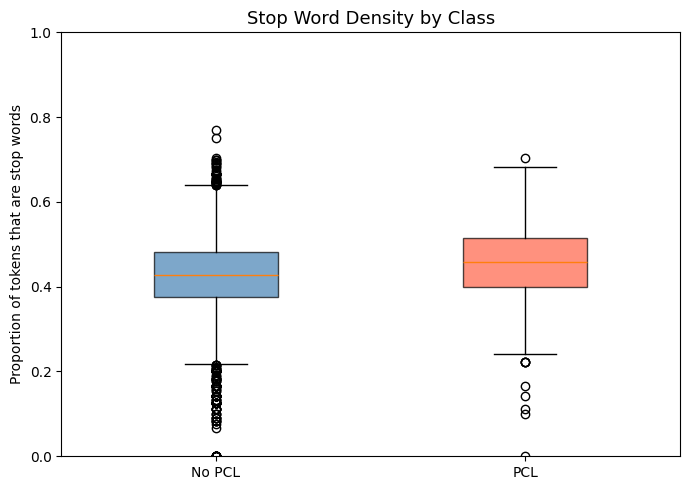

Figure 2d saved.


In [ ]:
# ---------------------------------------------------------------
# Figure 2d: Stop word density box plot by class
# ---------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5))

data_to_plot = [
    train_df[train_df['binary_label']==0]['stop_density'].values,
    train_df[train_df['binary_label']==1]['stop_density'].values
]
bp = ax.boxplot(data_to_plot, patch_artist=True, labels=['No PCL', 'PCL'], widths=0.4)
for patch, color in zip(bp['boxes'], ['steelblue', 'tomato']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Stop Word Density by Class', fontsize=13)
ax.set_ylabel('Proportion of tokens that are stop words', fontsize=10)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('eda_technique2d_stopword_density.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2d saved.')


## Exercise 4: Model Training

### Setup: Install and Import

In [ ]:
# Install HuggingFace Transformers and related libraries
!pip install transformers datasets -q

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    RobertaTokenizerFast,
    RobertaForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.metrics import f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Use GPU if available
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [ ]:

DATA_PATH = ''

df = pd.read_csv(
    DATA_PATH + 'dontpatronizeme_pcl.tsv',
    sep='\t',
    header=None,
    names=['par_id', 'art_id', 'keyword', 'country_code', 'text', 'label'],
    skiprows=4,
    quoting=3
)

df['label'] = df['label'].astype(int)
df['binary_label'] = (df['label'] >= 2).astype(int)
df['par_id'] = df['par_id'].astype(str).str.strip()

def load_par_ids(filepath):
    ids = set()
    with open(filepath, 'r') as f:
        next(f)  # skip header
        for line in f:
            line = line.strip()
            if line:
                ids.add(line.split(',')[0].strip())
    return ids

train_ids = load_par_ids(DATA_PATH + 'train_semeval_parids-labels.csv')
dev_ids   = load_par_ids(DATA_PATH + 'dev_semeval_parids-labels.csv')

train_df = df[df['par_id'].isin(train_ids)].reset_index(drop=True)
dev_df   = df[df['par_id'].isin(dev_ids)].reset_index(drop=True)

print(f'Train: {len(train_df)} | Dev: {len(dev_df)}')
print(f'Train PCL: {train_df["binary_label"].sum()} | Train No-PCL: {(train_df["binary_label"]==0).sum()}')

Train: 8375 | Dev: 2094
Train PCL: 794 | Train No-PCL: 7581


In [ ]:
# pip install -q transformers datasets accelerate scikit-learn torch

import os
import numpy as np
import torch

from sklearn.metrics import f1_score
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding, set_seed
)

set_seed(42)

# ---------------------------
# 1) Config
# ---------------------------
MODEL_NAME = "roberta-base"
OUTPUT_DIR = "./bestmodel_roberta_base"

TEXT_COL = "text"
LABEL_COL = "binary_label"

MAX_LENGTH = 192
BATCH_SIZE = 16
LR = 2e-5
EPOCHS = 4
WEIGHT_DECAY = 0.01
WARMUP_STEPS = 300  # explicit warmup

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------------------------
# 2) Ensure labels are ints AND text is string
# ---------------------------
train_df[LABEL_COL] = train_df[LABEL_COL].astype(int)
dev_df[LABEL_COL]   = dev_df[LABEL_COL].astype(int)

# Ensure text column is string and handle potential NaNs
train_df[TEXT_COL] = train_df[TEXT_COL].fillna('').astype(str)
dev_df[TEXT_COL] = dev_df[TEXT_COL].fillna('').astype(str)

# ---------------------------
# 3) Build HF Datasets (labels must be named "labels")
# ---------------------------
train_ds = Dataset.from_pandas(train_df[[TEXT_COL, LABEL_COL]], preserve_index=False)
dev_ds   = Dataset.from_pandas(dev_df[[TEXT_COL, LABEL_COL]], preserve_index=False)

train_ds = train_ds.rename_column(LABEL_COL, "labels")
dev_ds   = dev_ds.rename_column(LABEL_COL, "labels")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

def tokenize(batch):
    return tokenizer(batch[TEXT_COL], truncation=True, max_length=MAX_LENGTH)

train_ds = train_ds.map(tokenize, batched=True, remove_columns=[TEXT_COL])
dev_ds   = dev_ds.map(tokenize, batched=True, remove_columns=[TEXT_COL])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# ---------------------------
# 4) Model
# ---------------------------
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# ---------------------------
# 5) Metrics: best-threshold F1 for positive class
# ---------------------------
THRESHOLDS = np.linspace(0.05, 0.95, 19)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]

    # F1 at 0.5 (reference)
    preds_05 = (probs >= 0.5).astype(int)
    f1_05 = f1_score(labels, preds_05, pos_label=1)

    # Best threshold F1
    best_f1 = -1.0
    best_thr = 0.5
    for t in THRESHOLDS:
        f1 = f1_score(labels, (probs >= t).astype(int), pos_label=1)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = t

    return {
        "f1_pos@0.5": float(f1_05),
        "best_f1_pos": float(best_f1),
        "best_thr": float(best_thr),
    }

# ---------------------------
# 6) Training args
#   IMPORTANT: your env uses eval_strategy, not evaluation_strategy
# ---------------------------
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,

    metric_for_best_model="best_f1_pos",
    greater_is_better=True,

    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=WEIGHT_DECAY,

    warmup_steps=WARMUP_STEPS,

    fp16=False,
    bf16=False,

    max_grad_norm=1.0,
    logging_steps=100,
    report_to="none",
    save_total_limit=2,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=dev_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

# ---------------------------
# 7) Final dev predictions using best threshold
# ---------------------------
pred = trainer.predict(dev_ds)
logits = pred.predictions
labels = pred.label_ids
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]

best_f1 = -1.0
best_thr = 0.5
for t in THRESHOLDS:
    f1 = f1_score(labels, (probs >= t).astype(int), pos_label=1)
    if f1 > best_f1:
        best_f1 = f1
        best_thr = t

print(f"FINAL Best Dev F1(pos): {best_f1:.4f} at threshold {best_thr:.2f}")

dev_preds = (probs >= best_thr).astype(int)

dev_out_path = os.path.join(OUTPUT_DIR, "dev.txt")
with open(dev_out_path, "w") as f:
    for y in dev_preds:
        f.write(f"{int(y)}\n")

print("Wrote:", dev_out_path)

# Save model + tokenizer
model_dir = os.path.join(OUTPUT_DIR, "model")
os.makedirs(model_dir, exist_ok=True)
trainer.save_model(model_dir)
tokenizer.save_pretrained(model_dir)
print("Saved model to:", model_dir)


Map:   0%|          | 0/8375 [00:00<?, ? examples/s]

Map:   0%|          | 0/2094 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Pos@0.5,Best F1 Pos,Best Thr
1,0.255806,0.222288,0.549801,0.549801,0.500000
2,0.193360,0.235527,0.566893,0.576744,0.550000
3,0.120598,0.274131,0.520635,0.588529,0.050000
4,0.057355,0.407296,0.588235,0.602597,0.900000


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

FINAL Best Dev F1(pos): 0.6026 at threshold 0.90
Wrote: ./bestmodel_roberta_base/dev.txt


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to: ./bestmodel_roberta_base/model


In [ ]:
import pandas as pd
import torch
import numpy as np
import os
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    DataCollatorWithPadding,
    TrainingArguments
)

# ---------------------------
# 1) Paths
# ---------------------------
MODEL_DIR = "./bestmodel_roberta_base/model"
OUTPUT_DIR = "./bestmodel_roberta_base"

TEST_FILE = "task4_test.tsv"
TEXT_COL = "text"
MAX_LENGTH = 192

# IMPORTANT:
# Replace with your saved threshold value from dev
best_thr = 0.9

# ---------------------------
# 2) Load model + tokenizer
# ---------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Minimal inference-only TrainingArguments
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_eval_batch_size=32,
    do_train=False,
    do_predict=True,
    logging_strategy="no",
    report_to="none"
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
)

# ---------------------------
# 3) Load test TSV
# ---------------------------
test_df = pd.read_csv(
    TEST_FILE,
    sep="\t",
    header=None,
    names=["par_id", "art_id", "keyword", "country_code", "text"],
    quoting=3
)

print("Test size:", len(test_df))
print(test_df.head())

assert TEXT_COL in test_df.columns, f"{TEXT_COL} column not found!"

# ---------------------------
# 4) Build Dataset
# ---------------------------
test_ds = Dataset.from_pandas(
    test_df[[TEXT_COL]],
    preserve_index=False
)

def tokenize(batch):
    return tokenizer(
        batch[TEXT_COL],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

test_ds = test_ds.map(
    tokenize,
    batched=True,
    remove_columns=[TEXT_COL]
)

# ---------------------------
# 5) Predict probabilities
# ---------------------------
pred = trainer.predict(test_ds)

logits = pred.predictions
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]

test_preds = (probs >= best_thr).astype(int)

# ---------------------------
# 6) Write test.txt
# ---------------------------
os.makedirs(OUTPUT_DIR, exist_ok=True)
test_out_path = os.path.join(OUTPUT_DIR, "test.txt")

with open(test_out_path, "w") as f:
    for y in test_preds:
        f.write(f"{int(y)}\n")

print("Wrote:", test_out_path)
print("Used threshold:", best_thr)
print("Total predictions:", len(test_preds))


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Test size: 3832
  par_id      art_id     keyword country_code  \
0    t_0   @@7258997  vulnerable           us   
1    t_1  @@16397324       women           pk   
2    t_2  @@16257812     migrant           ca   
3    t_3   @@3509652     migrant           gb   
4    t_4    @@477506  vulnerable           ca   

                                                text  
0  In the meantime , conservatives are working to...  
1  In most poor households with no education chil...  
2  The real question is not whether immigration i...  
3  In total , the country 's immigrant population...  
4  Members of the church , which is part of Ken C...  


Map:   0%|          | 0/3832 [00:00<?, ? examples/s]

Wrote: ./bestmodel_roberta_base/test.txt
Used threshold: 0.9
Total predictions: 3832


### Exercise 5.2: Error Analysis and Local Evaluation

Confusion matrix:
 [[1825   70]
 [  83  116]] 

Classification report:

              precision    recall  f1-score   support

           0     0.9565    0.9631    0.9598      1895
           1     0.6237    0.5829    0.6026       199

    accuracy                         0.9269      2094
   macro avg     0.7901    0.7730    0.7812      2094
weighted avg     0.9249    0.9269    0.9258      2094



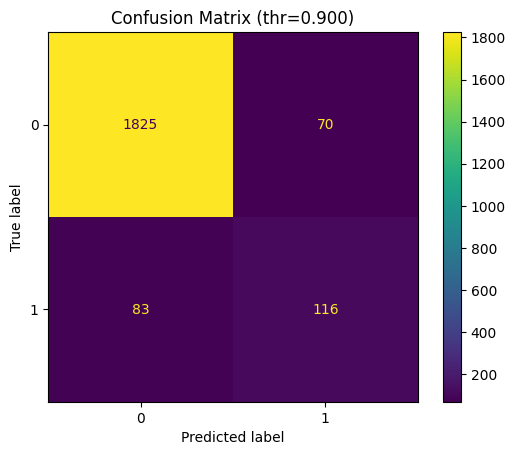

In [ ]:
# ============================================================
# 1) Confusion Matrix
# ============================================================

import re
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    f1_score
)
import matplotlib.pyplot as plt

TEXT_COL = "text"
LABEL_COL = "binary_label"


pred_dev = trainer.predict(dev_ds)
logits_dev = pred_dev.predictions
y_true = pred_dev.label_ids.astype(int)

p_pcl = torch.softmax(torch.tensor(logits_dev), dim=-1).numpy()[:, 1]   # P(class=1)
y_pred = (p_pcl >= best_thr).astype(int)

err = dev_df.copy().reset_index(drop=True)

if LABEL_COL in err.columns:
    err["y_true"] = err[LABEL_COL].astype(int)
else:
    err["y_true"] = y_true

err["p_pcl"] = p_pcl
err["y_pred"] = y_pred
err["correct"] = (err["y_true"].values == err["y_pred"].values)
err["margin"] = np.abs(err["p_pcl"] - best_thr)

err["n_words"] = err[TEXT_COL].astype(str).apply(lambda s: len(s.split()))

def assign_case(row):
    if row["y_true"] == 0 and row["y_pred"] == 1:
        return "FP"
    if row["y_true"] == 1 and row["y_pred"] == 0:
        return "FN"
    if row["y_true"] == 1 and row["y_pred"] == 1:
        return "TP"
    return "TN"

err["case"] = err.apply(assign_case, axis=1)

cm = confusion_matrix(err["y_true"], err["y_pred"])
print("Confusion matrix:\n", cm, "\n")
print("Classification report:\n")
print(classification_report(err["y_true"], err["y_pred"], digits=4))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(values_format="d")
plt.title(f"Confusion Matrix (thr={best_thr:.3f})")
plt.show()



In [ ]:
# ============================================================
# 2) False Positives Analysis
# ============================================================

def show_examples(df, case, n=10):
    if case == "FP":
        # predicted PCL with high confidence, but actually not PCL
        ex = df[df["case"]=="FP"].sort_values("p_pcl", ascending=False).head(n)
    elif case == "FN":
        # missed true PCL with low p_pcl (confidently wrong)
        ex = df[df["case"]=="FN"].sort_values("p_pcl", ascending=True).head(n)
    else:
        ex = df[df["case"]==case].head(n)

    cols = ["p_pcl", "y_true", "y_pred", "keyword", "country_code", "n_words", "text"]
    return ex[cols]

show_examples(err, "FP", n=25)

,p_pcl,y_true,y_pred,keyword,country_code,n_words,text
972,0.998425,0,1,refugee,us,64,In an act of defiance against Hungarian author...
1687,0.998403,0,1,in-need,za,36,"""Adopt a Mission serves as a platform for the ..."
1745,0.998401,0,1,poor-families,ke,44,""""""" We have identified extremely poor families..."
416,0.998366,0,1,refugee,ke,19,"""E-mail Address : * <h> A clinic called """" Hop..."
1252,0.998343,0,1,poor-families,ng,72,Usually children of poor families remember the...
1140,0.998329,0,1,hopeless,nz,41,""""""" It beggars belief this scheme has been cob..."
1557,0.998304,0,1,vulnerable,jm,26,"Meanwhile , Dr. Thomas told JIS News that the ..."
1510,0.998257,0,1,hopeless,jm,46,""""""" Is it the bad gas , the ZIKV , is it the j..."
715,0.998216,0,1,in-need,my,40,Jesus begins his teaching in Matthew with the ...
254,0.998147,0,1,hopeless,au,31,""""""" So we do need to heal ourselves as an Abor..."


In [ ]:
# ============================================================
# 3) False Negatives Analysis
# ============================================================

show_examples(err, "FN", n=25)

,p_pcl,y_true,y_pred,keyword,country_code,n_words,text
150,0.000216,1,0,disabled,hk,32,Cheung said 20 disabled undergraduate students...
121,0.000264,1,0,poor-families,us,37,The World Health Organization did not give a r...
35,0.000269,1,0,women,za,76,"""Mari ? tte Coetzee from Stofberg Family Viney..."
163,0.000282,1,0,refugee,ng,16,Many refugees do n't want to be resettled anyw...
464,0.000352,1,0,poor-families,pk,45,A massive cleanup and awareness drive was cond...
52,0.000353,1,0,immigrant,gh,74,"""Nearly 15,000 West African teenagers leave th..."
108,0.000387,1,0,hopeless,bd,44,"""Calling for an immediate political solution t..."
42,0.000424,1,0,hopeless,pk,47,The Global Gender Gap Report 2016 has ranked P...
12,0.000459,1,0,homeless,ie,30,"It 's calculated that over 204,000 days of pur..."
155,0.000496,1,0,poor-families,ng,38,""""""" Nigeria 's tertiary education system is st..."


In [ ]:
# ============================================================
# 4) Group substitution
# ============================================================

import re
import numpy as np
import pandas as pd
import torch
from datasets import Dataset

# Define suitable substitution pairs
SUB_PAIRS = [
    ("women", "men"),
    ("immigrant", "citizen"),
    ("migrant", "local resident"),
    ("refugee", "citizen"),
    ("homeless", "housed"),
    ("disabled", "able-bodied"),
    ("poor-families", "wealthy families"),
    ("in-need", "well-off"),
]

def _surface_forms(keyword: str):
    """
    Generate surface forms to match in text.
    Handles hyphenated keywords by adding a spaced variant.
    Example: "poor-families" -> ["poor-families", "poor families"]
    """
    forms = [keyword]
    if "-" in keyword:
        forms.append(keyword.replace("-", " "))
    seen = set()
    out = []
    for f in forms:
        if f not in seen:
            out.append(f)
            seen.add(f)
    return out

def substitute_group(text: str, src_keyword: str, tgt_phrase: str) -> str:
    """
    Replace occurrences of src_keyword (and its surface variants) with tgt_phrase
    using case-insensitive, word-boundary matching.
    """
    s = str(text)
    for src_form in _surface_forms(src_keyword):
        pattern = re.compile(r"\b" + re.escape(src_form) + r"\b", flags=re.IGNORECASE)
        s = pattern.sub(tgt_phrase, s)
    return s

def predict_p1_texts(texts, batch_size=32):
    """
    Predict P(class=1) for raw texts using the existing `trainer`+`tokenizer`.
    """
    tmp_df = pd.DataFrame({TEXT_COL: list(texts)})
    tmp_ds = Dataset.from_pandas(tmp_df, preserve_index=False)

    def tok(batch):
        return tokenizer(batch[TEXT_COL], truncation=True, padding=True)

    tmp_ds = tmp_ds.map(tok, batched=True, remove_columns=[TEXT_COL])
    out = trainer.predict(tmp_ds)
    p1 = torch.softmax(torch.tensor(out.predictions), dim=-1).numpy()[:, 1]
    return p1

# Run substitution analysis
sub_rows = []

for src, tgt in SUB_PAIRS:
    # Focus on rows where the example's keyword equals the source keyword
    # (so the substitution is relevant/meaningful).
    mask = err["keyword"].astype(str).str.lower() == src.lower()
    sub = err[mask].copy()
    if len(sub) == 0:
        continue

    sub["src"] = src
    sub["tgt"] = tgt
    sub["text_cf"] = sub[TEXT_COL].apply(lambda t: substitute_group(t, src, tgt))

    # Keep only rows where something actually changed
    changed = sub["text_cf"] != sub[TEXT_COL].astype(str)
    sub = sub[changed].copy()
    if len(sub) == 0:
        continue

    # Predict counterfactual probabilities
    sub["p_cf"] = predict_p1_texts(sub["text_cf"].tolist())
    sub["delta_p"] = sub["p_cf"] - sub["p_pcl"]

    sub["y_pred_cf"] = (sub["p_cf"] >= best_thr).astype(int)
    sub["flip"] = (sub["y_pred_cf"] != sub["y_pred"]).astype(int)

    sub_rows.append(sub)

if len(sub_rows) == 0:
    print("No substitution results: no rows matched or no text changes occurred.")
else:
    sub_all = pd.concat(sub_rows, ignore_index=True)

    # Summary per substitution pair
    summary = (
        sub_all.groupby(["src", "tgt"], dropna=False)
        .agg(
            n=("src", "size"),
            avg_p_orig=("p_pcl", "mean"),
            avg_p_cf=("p_cf", "mean"),
            avg_delta_p=("delta_p", "mean"),
            med_delta_p=("delta_p", "median"),
            flip_rate=("flip", "mean"),
        )
        .sort_values(["flip_rate", "avg_delta_p"], ascending=[False, False])
        .reset_index()
    )

    display(summary)

    # Show the most sensitive examples overall
    sub_all["abs_delta"] = sub_all["delta_p"].abs()
    most_sensitive = sub_all.sort_values("abs_delta", ascending=False).head(20)

    display(
        most_sensitive[
            ["src", "tgt", "p_pcl", "p_cf", "delta_p", "flip",
             "keyword", "country_code", TEXT_COL, "text_cf"]
        ]
    )

Map:   0%|          | 0/232 [00:00<?, ? examples/s]

Map:   0%|          | 0/65 [00:00<?, ? examples/s]

Map:   0%|          | 0/34 [00:00<?, ? examples/s]

Map:   0%|          | 0/74 [00:00<?, ? examples/s]

Map:   0%|          | 0/187 [00:00<?, ? examples/s]

Map:   0%|          | 0/194 [00:00<?, ? examples/s]

Map:   0%|          | 0/189 [00:00<?, ? examples/s]

Map:   0%|          | 0/210 [00:00<?, ? examples/s]

,src,tgt,n,avg_p_orig,avg_p_cf,avg_delta_p,med_delta_p,flip_rate
0,poor-families,wealthy families,189,0.175847,0.105082,-0.070766,-0.000184,0.063492
1,homeless,housed,187,0.158323,0.112700,-0.045623,-0.000031,0.058824
2,women,men,232,0.039770,0.029690,-0.010080,-0.000003,0.017241
3,immigrant,citizen,65,0.028311,0.029820,0.001509,-0.000002,0.015385
4,in-need,well-off,210,0.211787,0.206439,-0.005348,-0.000009,0.014286
5,disabled,able-bodied,194,0.072320,0.062501,-0.009819,-0.000006,0.010309
6,migrant,local resident,34,0.032684,0.029889,-0.002795,-0.000020,0.000000
7,refugee,citizen,74,0.063674,0.054033,-0.009641,-0.000001,0.000000


,src,tgt,p_pcl,p_cf,delta_p,flip,keyword,country_code,text,text_cf
792,poor-families,wealthy families,0.995198,0.000722,-0.994476,1,poor-families,us,""""""" The worst thing was dealt to us , """" he sa...",""""""" The worst thing was dealt to us , """" he sa..."
814,poor-families,wealthy families,0.995511,0.004623,-0.990887,1,poor-families,za,""""""" As a family , my father was a policeman an...",""""""" As a family , my father was a policeman an..."
817,poor-families,wealthy families,0.996645,0.006977,-0.989667,1,poor-families,ph,Marcos said the government should help poor fa...,Marcos said the government should help wealthy...
454,homeless,housed,0.995634,0.007098,-0.988535,1,homeless,in,"""Black grew up in the neighbourhood around the...","""Black grew up in the neighbourhood around the..."
802,poor-families,wealthy families,0.990885,0.008802,-0.982083,1,poor-families,us,McAfee said he was helping the locals by feedi...,McAfee said he was helping the locals by feedi...
888,poor-families,wealthy families,0.975724,0.001826,-0.973898,1,poor-families,jm,""""""" T-Bird was observant but soft spoken . Onl...",""""""" T-Bird was observant but soft spoken . Onl..."
468,homeless,housed,0.998009,0.025421,-0.972588,1,homeless,ph,The homeless pitch in whatever money they have...,The housed pitch in whatever money they have s...
794,poor-families,wealthy families,0.977346,0.007962,-0.969384,1,poor-families,nz,For ten years a group of women have been stitc...,For ten years a group of women have been stitc...
873,poor-families,wealthy families,0.973351,0.033079,-0.940271,1,poor-families,pk,He said all Daanish schools had been set up in...,He said all Daanish schools had been set up in...
947,poor-families,wealthy families,0.959444,0.019719,-0.939725,1,poor-families,tz,"Five years down the lane , the schools whose l...","Five years down the lane , the schools whose l..."
